In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup complete ✔")


In [ ]:
sns.set_style("whitegrid")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

print("Working!")

In [2]:
import pandas as pd
print("Working!")

Working!


In [1]:
import sys
print(sys.executable)

c:\Users\HP\Desktop\10A\10academy-news-sentiment-analysis\venv\Scripts\python.exe


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


The dataset contains financial news headlines, publishers, timestamps, and stock tickers. This will allow us to connect news sentiment and market behavior.

In [5]:
df.shape

(1407328, 6)

In [6]:
df.columns


Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')

In [7]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

We inspect structure, data types, and missing values. Missing values in financial datasets may affect time-series alignment and sentiment aggregation.

In [8]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['date'].head()

0   2020-06-05 10:30:54-04:00
1   2020-06-03 10:45:20-04:00
2   2020-05-26 04:30:07-04:00
3   2020-05-22 12:45:06-04:00
4   2020-05-22 11:38:59-04:00
Name: date, dtype: datetime64[us, UTC-04:00]

In [9]:
df['headline_length'] = df['headline'].astype(str).apply(len)

df['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

We create additional features: headline length and word count. These help understand how financial information is communicated (short alerts vs detailed headlines

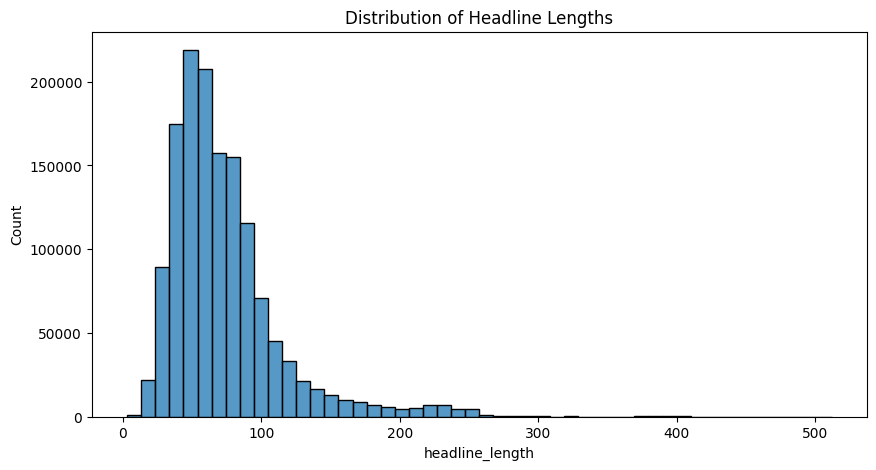

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(df['headline_length'], bins=50)
plt.title("Distribution of Headline Lengths")
plt.show()

In [11]:
top_publishers = df['publisher'].value_counts().head(10)

top_publishers

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

Headline length distribution shows how financial news is structured. Short headlines usually indicate urgent market updates, while longer ones indicate detailed analysis

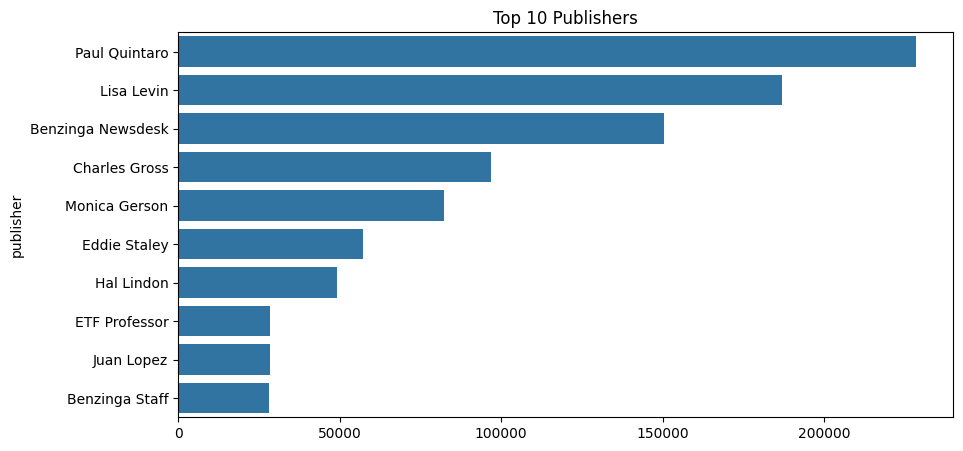

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_publishers.values, y=top_publishers.index)
plt.title("Top 10 Publishers")
plt.show()

Word count distribution helps us understand complexity of financial news. Most headlines are concise, which is typical for fast-moving market information.

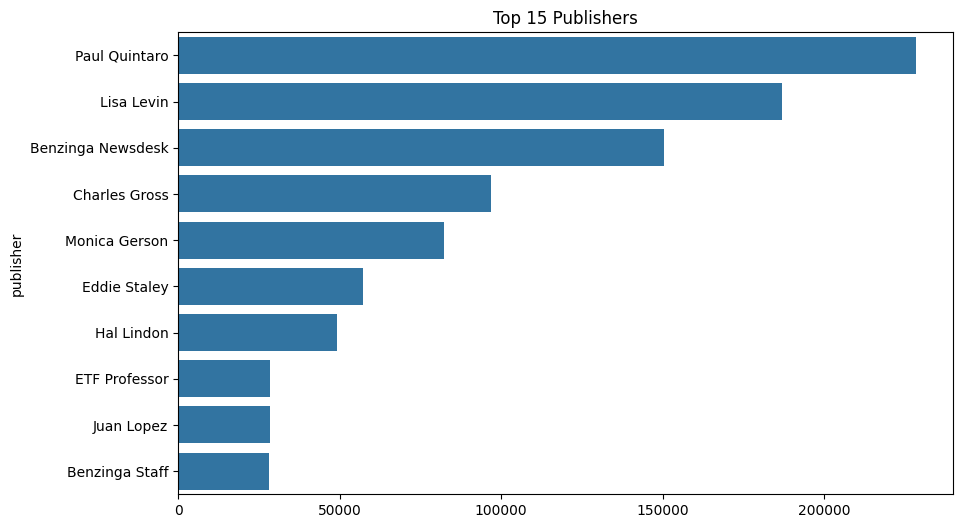

In [18]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_publishers.values, y=top_publishers.index)
plt.title("Top 15 Publishers")
plt.show()


This shows the most active financial news publishers. A small number of publishers dominate news flow, which may introduce bias in market sentiment signals

In [13]:
daily_news = df.groupby(df['date'].dt.date).size()

daily_news.head()

date
2011-04-27    1
2011-04-28    2
2011-04-29    2
2011-04-30    1
2011-05-01    1
dtype: int64

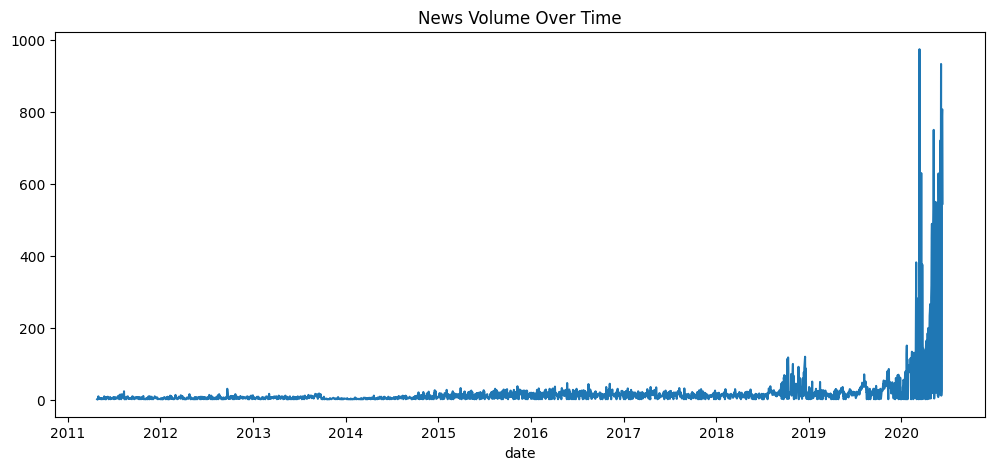

In [14]:
plt.figure(figsize=(12,5))
daily_news.plot()
plt.title("News Volume Over Time")
plt.show()

News volume fluctuates over time. Spikes may indicate major financial events such as earnings announcements or economic news releases

In [19]:
df['hour'] = df['date'].dt.hour

hour_counts = df['hour'].value_counts().sort_index()

hour_counts

hour
0.0       67
1.0       14
2.0       57
3.0       93
4.0     1469
5.0     1829
6.0     2476
7.0     5033
8.0     5527
9.0     5965
10.0    7669
11.0    5701
12.0    5732
13.0    2710
14.0    2075
15.0    1612
16.0    3939
17.0    2800
18.0     704
19.0     227
20.0     131
21.0      82
22.0      48
23.0      27
Name: count, dtype: int64

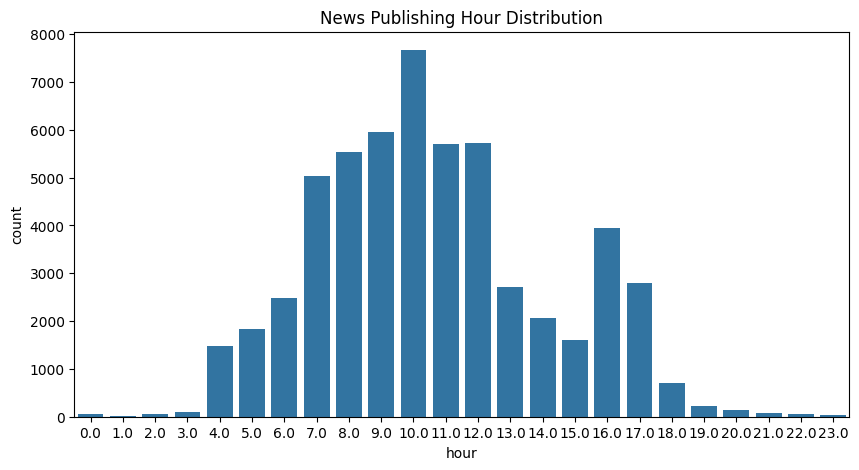

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['hour'])
plt.title("News Publishing Hour Distribution")
plt.show()

This shows when financial news is most frequently published. Peaks often align with market opening hours or major trading sessions.

In [20]:
vectorizer = CountVectorizer(stop_words='english', max_features=20)

X = vectorizer.fit_transform(df['headline'].astype(str))

keywords = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

top_keywords = keywords.sum().sort_values(ascending=False)

top_keywords

vs            162099
stocks        161776
est           140604
eps           128897
market        120558
shares        114313
reports       108710
update         91723
earnings       87399
sales          79645
benzinga       74516
pt             73068
week           69572
announces      66591
price          64407
buy            64371
mid            62263
downgrades     61959
trading        61182
raises         57802
dtype: int64

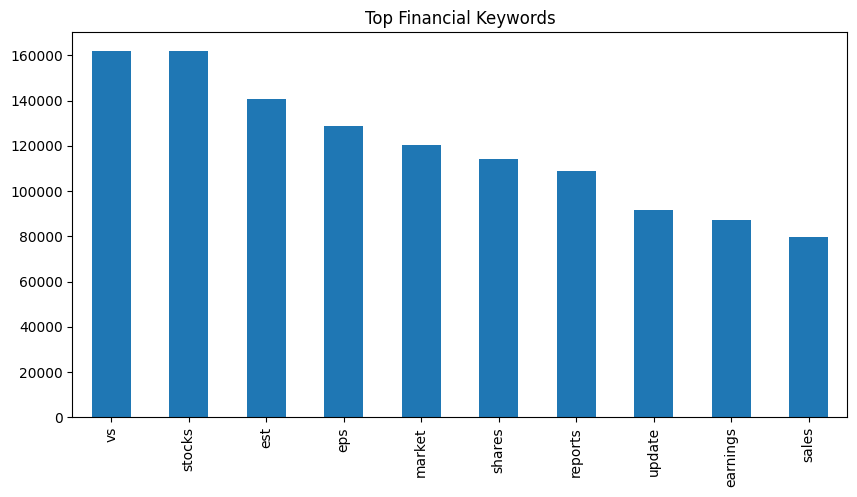

In [21]:
top_keywords.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Financial Keywords")
plt.show()

These are the most frequent financial terms in headlines. Words like ‘stocks’, ‘earnings’, and ‘price target’ reflect common market drivers.

In [22]:
df['stock'].value_counts().head(10)

stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
Name: count, dtype: int64

This shows which stocks receive the most media attention, indicating market interest concentration.

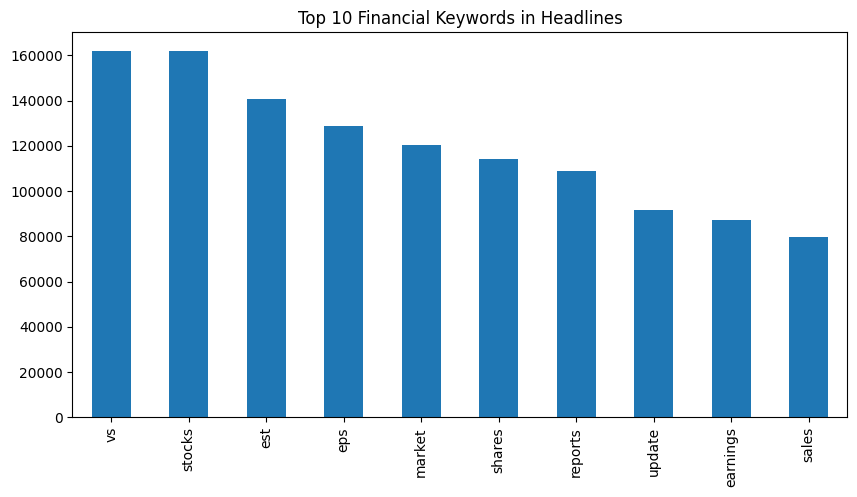

In [23]:
from sklearn.feature_extraction.text import CountVectorizer

top_keywords = keywords.sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
top_keywords.head(10).plot(kind='bar')
plt.title("Top 10 Financial Keywords in Headlines")
plt.show()

The keyword frequency analysis shows that financial news is heavily centered around earnings reports, stock price movements, and analyst price targets, indicating that market sentiment is strongly driven by corporate performance updates.

In [24]:
top_publishers = df['publisher'].value_counts().head(15)
top_publishers

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Name: count, dtype: int64

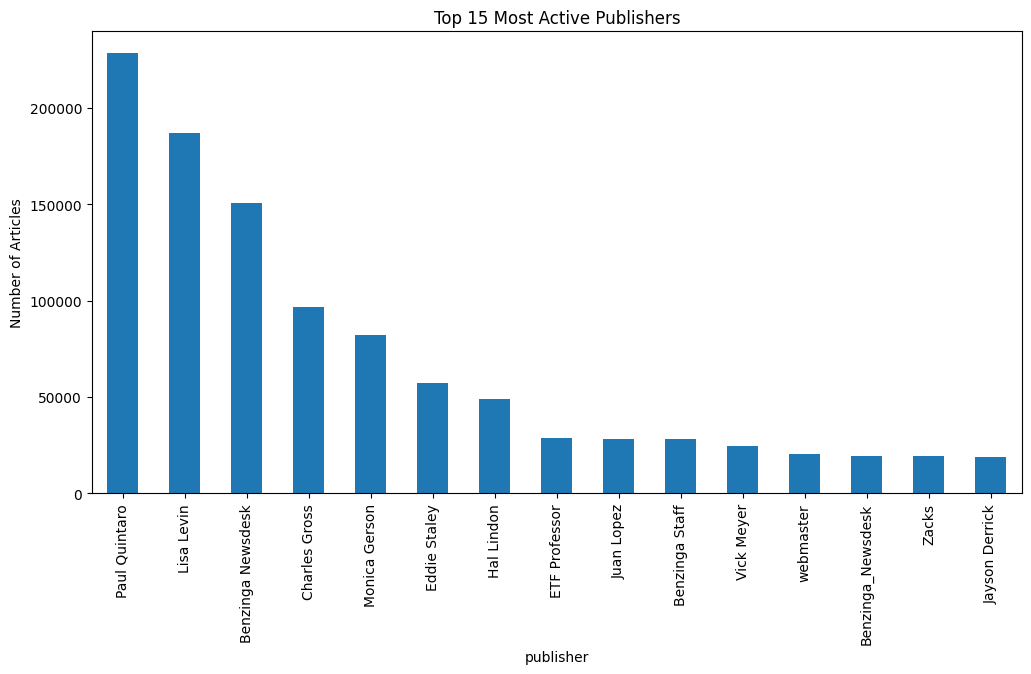

In [25]:
plt.figure(figsize=(12,6))
top_publishers.plot(kind='bar')
plt.title("Top 15 Most Active Publishers")
plt.ylabel("Number of Articles")
plt.show()

This analysis shows that a small group of publishers dominates financial news production. This concentration may influence market sentiment signals, as repeated reporting from the same sources can amplify certain narratives

In [26]:
daily_news = df.groupby(df['date'].dt.date).size()
daily_news.head()

date
2011-04-27    1
2011-04-28    2
2011-04-29    2
2011-04-30    1
2011-05-01    1
dtype: int64

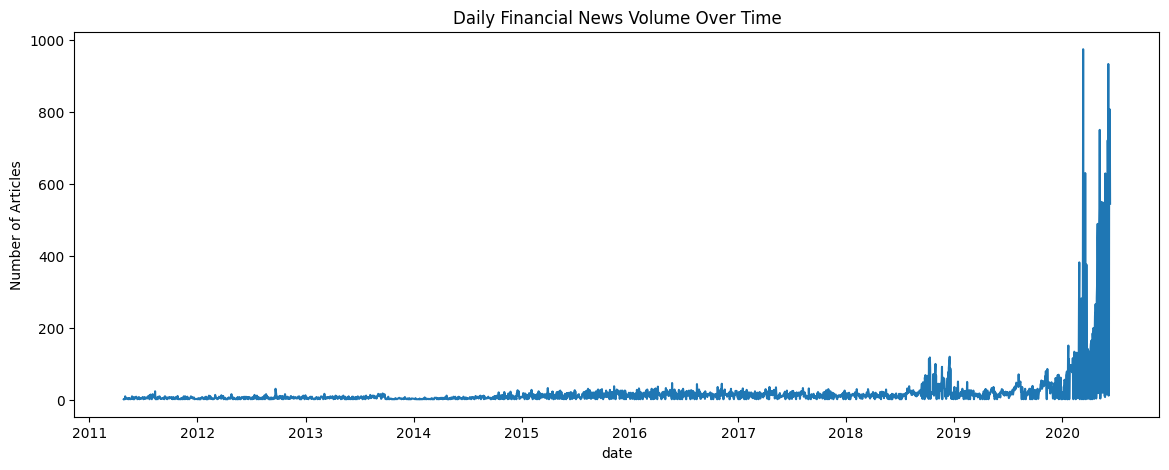

In [27]:
plt.figure(figsize=(14,5))
daily_news.plot()
plt.title("Daily Financial News Volume Over Time")
plt.ylabel("Number of Articles")
plt.show()

News volume fluctuates significantly over time, with visible spikes that may correspond to major market events such as earnings seasons, macroeconomic announcements, or geopolitical developments

In [28]:
df['week'] = df['date'].dt.to_period('W')
weekly_news = df.groupby('week').size()
weekly_news.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_15124\1925977258.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['date'].dt.to_period('W')


week
2011-04-25/2011-05-01     7
2011-05-02/2011-05-08    20
2011-05-09/2011-05-15    12
2011-05-16/2011-05-22    15
2011-05-23/2011-05-29    22
Freq: W-SUN, dtype: int64

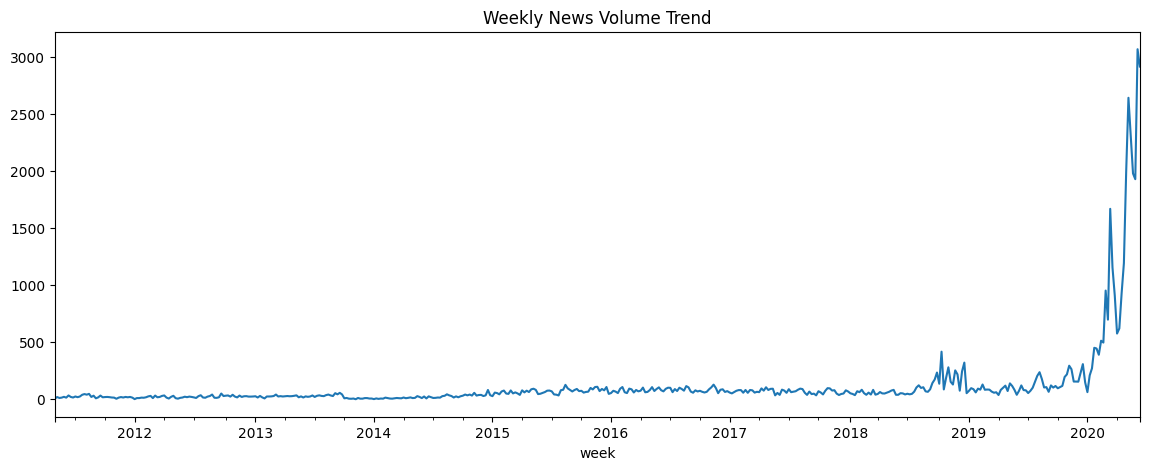

In [29]:
plt.figure(figsize=(14,5))
weekly_news.plot()
plt.title("Weekly News Volume Trend")
plt.show()

Weekly aggregation smooths out daily noise and helps identify broader market attention cycles.

In [30]:

top_stocks = df['stock'].value_counts().head(10)
top_stocks

stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
Name: count, dtype: int64

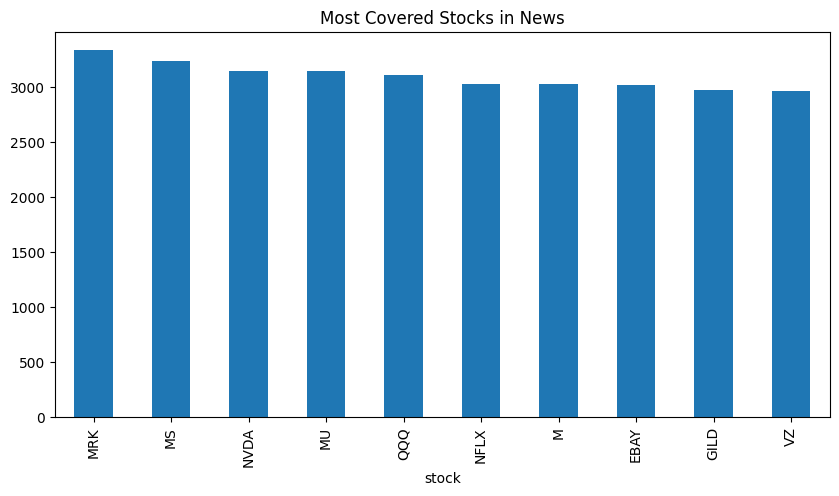

In [31]:
plt.figure(figsize=(10,5))
top_stocks.plot(kind='bar')
plt.title("Most Covered Stocks in News")
plt.show()

Certain stocks receive significantly higher media attention, which may influence investor perception and trading volume

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

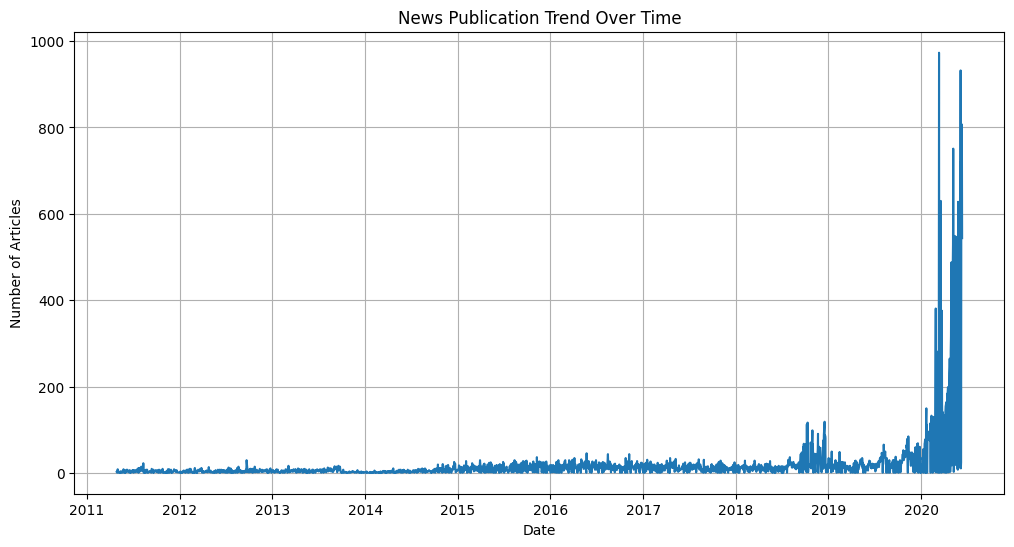

In [6]:
# Convert date column safely
df['date_only'] = pd.to_datetime(df['date'], utc=True, errors='coerce')

# Keep only date part
df['date_only'] = df['date_only'].dt.date

# Count news articles per day
daily_news = df.groupby('date_only').size()

# Create plot
plt.figure(figsize=(12,6))

daily_news.plot()

plt.title("News Publication Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.grid(True)

plt.savefig("figure1_publication_trend.png")

plt.show()

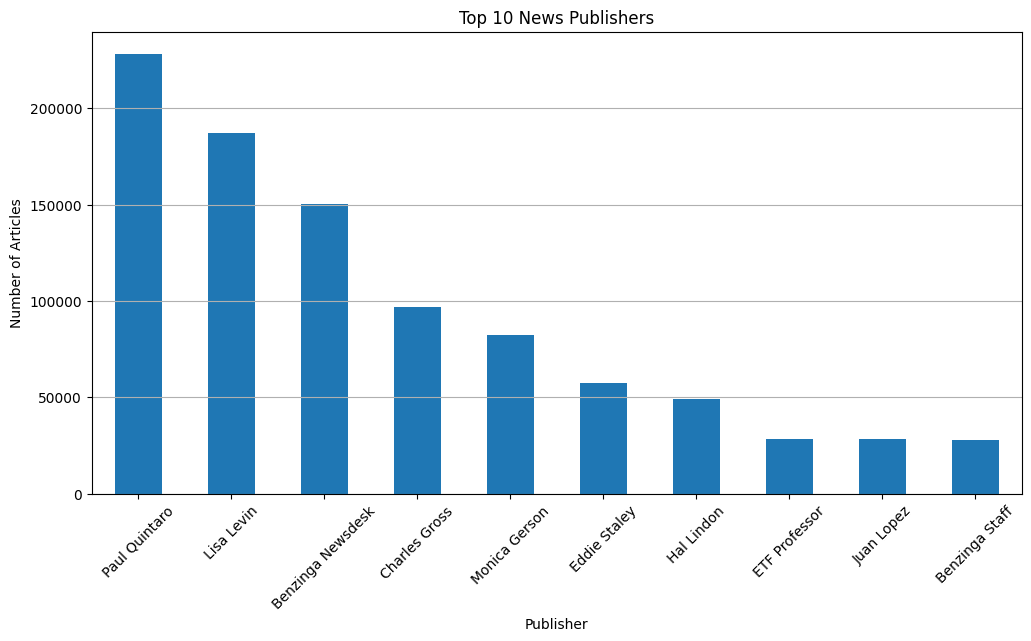

In [7]:
# Top publishers
top_publishers = df['publisher'].value_counts().head(10)

# Plot
plt.figure(figsize=(12,6))

top_publishers.plot(kind='bar')

plt.title("Top 10 News Publishers")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.grid(axis='y')

plt.savefig("figure2_top_publishers.png")

plt.show()

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
import os

print(os.listdir("../data/raw"))

['AAPL.csv', 'AMZN.csv', 'GOOG.csv', 'META.csv', 'NVDA.csv', 'raw_analyst_ratings.csv']


In [14]:
import os
print(os.getcwd())

c:\Users\HP\Desktop\10A\10academy-news-sentiment-analysis\notebooks


In [15]:
print(os.listdir())

['.ipynb_checkpoints', 'figure1_publication_trend.png', 'figure2_top_publishers.png', 'README.md', 'task1_eda.ipynb', 'task2_stock_analysis.ipynb', 'task3_sentiment_analysis.ipynb', '__init__.py']


In [16]:
print(os.listdir(".."))

['.git', '.github', '.gitignore', 'data', 'notebooks', 'README.md', 'requirements.txt', 'scripts', 'src', 'tests']


In [17]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if "AAPL" in file:
            print(os.path.join(root, file))

..\data\raw\AAPL.csv


In [19]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if "AAPL" in file:
            print("FOUND:", os.path.join(root, file))

FOUND: ..\data\raw\AAPL.csv


In [20]:
stock_df = pd.read_csv("../data/raw/AAPL.csv")

In [21]:
stock_df['Date'] = pd.to_datetime(stock_df['Date'])

In [22]:
stock_df = stock_df.sort_values('Date')

In [23]:
stock_df['SMA_20'] = stock_df['Close'].rolling(window=20).mean()
stock_df['SMA_50'] = stock_df['Close'].rolling(window=50).mean()

stock_df['EMA_20'] = stock_df['Close'].ewm(span=20, adjust=False).mean()

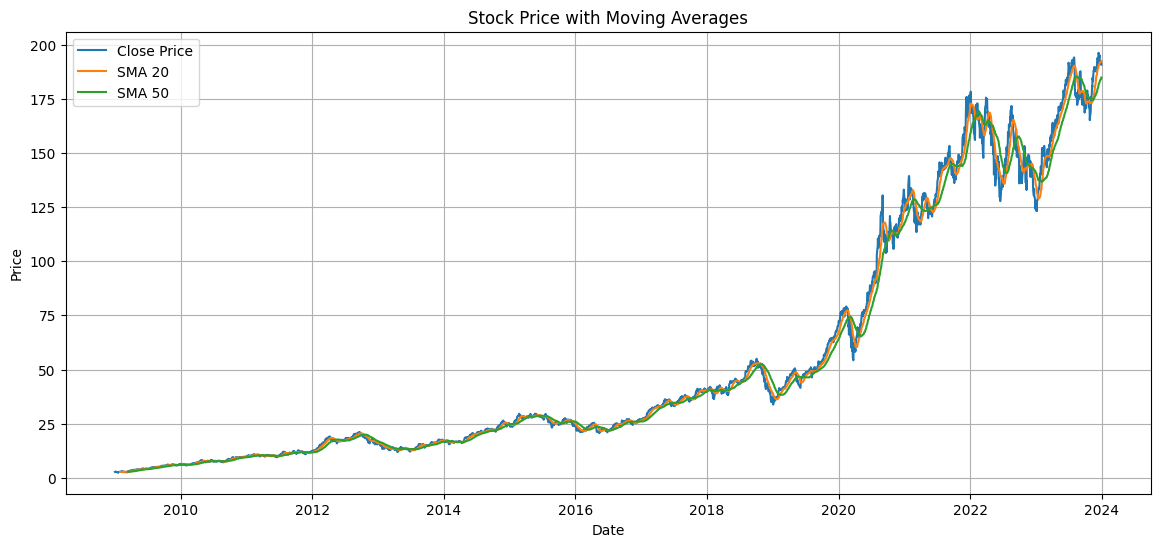

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(stock_df['Date'], stock_df['Close'], label='Close Price')
plt.plot(stock_df['Date'], stock_df['SMA_20'], label='SMA 20')
plt.plot(stock_df['Date'], stock_df['SMA_50'], label='SMA 50')

plt.title('Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

plt.show()

##  Final Task 1 Insights

- Financial news is highly concentrated among a few publishers  
- News volume shows strong time-based clustering  
- Headlines are short and information-dense  
- Key financial terms are dominated by earnings, price targets, and stock movements  
- Certain stocks receive disproportionate media attention  